# Assignment 1: Understanding Generative and Discriminative Models Using MNIST


## STEP 1: Import Libraries

In [24]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

from tensorflow.keras.datasets import mnist
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

## STEP 2: Dataset

Training samples : 12665
Testing  samples : 2115


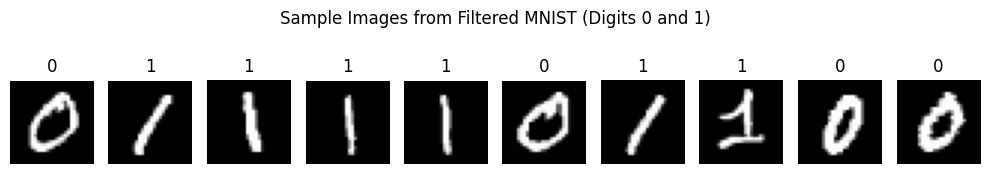

In [21]:
(X_train_full, y_train_full), (X_test_full, y_test_full) = mnist.load_data()

# Filter to keep only 0s and 1s
train_mask = (y_train_full == 0) | (y_train_full == 1)
test_mask  = (y_test_full  == 0) | (y_test_full  == 1)

X_train = X_train_full[train_mask]
y_train = y_train_full[train_mask]
X_test  = X_test_full[test_mask]
y_test  = y_test_full[test_mask]

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

X_train_norm = X_train.astype('float32') / 255.0
X_test_norm  = X_test.astype('float32')  / 255.0

# Visualize a few samples
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(str(y_train[i]))
    plt.axis('off')
plt.suptitle('Sample Images from Filtered MNIST (Digits 0 and 1)')
plt.tight_layout()
plt.show()

##STEP 3: Discriminative Model — Logistic Regression

In [19]:
# Flatten images: (28, 28) → (784,)
X_train_flat = X_train_norm.reshape(X_train_norm.shape[0], -1)
X_test_flat  = X_test_norm.reshape(X_test_norm.shape[0],  -1)

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_flat, y_train)

# Evaluate
y_pred = lr_model.predict(X_test_flat)
accuracy = accuracy_score(y_test, y_pred)
print(f"Discriminative Model (Logistic Regression) Accuracy: {accuracy * 100:.2f}%")

Discriminative Model (Logistic Regression) Accuracy: 99.95%


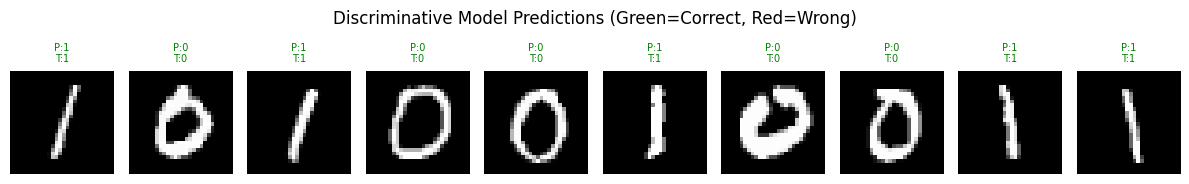

In [17]:
# show a few predictions
plt.figure(figsize=(12, 2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(X_test[i], cmap='gray')
    color = 'green' if y_pred[i] == y_test[i] else 'red'
    plt.title(f"P:{y_pred[i]}\nT:{y_test[i]}", fontsize=7, color=color)
    plt.axis('off')
plt.suptitle('Discriminative Model Predictions (Green=Correct, Red=Wrong)')
plt.tight_layout()
plt.show()


#Step 4: Generative Model - Autoencoder

In [25]:
# Flatten for Dense autoencoder
X_train_ae = X_train_norm.reshape(-1, 784)
X_test_ae  = X_test_norm.reshape(-1, 784)

# Build Autoencoder
input_img = Input(shape=(784,))

# Encoder
x = Dense(128, activation='relu')(input_img)
encoded = Dense(32, activation='relu')(x)

# Decoder
x = Dense(128, activation='relu')(encoded)
decoded = Dense(784, activation='sigmoid')(x)

# Autoencoder model
autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,968 (820.19 KB)

 Trainable params: 209,968 (820.19 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# train autoencoder
history = autoencoder.fit(
    X_train_ae, X_train_ae,
    epochs=20,
    batch_size=128,
    validation_data=(X_test_ae, X_test_ae),
    verbose=1
)


Epoch 1/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.2521 - val_loss: 0.1478
Epoch 2/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1329 - val_loss: 0.1196
Epoch 3/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1138 - val_loss: 0.1048
Epoch 4/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1010 - val_loss: 0.0945
Epoch 5/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0933 - val_loss: 0.0888
Epoch 6/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0880 - val_loss: 0.0846
Epoch 7/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0842 - val_loss: 0.0812
Epoch 8/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0815 - val_loss: 0.0794
Epoch 9/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0795 - val_loss: 0.0774
Epoch 10/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0781 - val_loss: 0.0767
Epoch 11/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0768 - val_loss: 0.0755
Epoch 12/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0

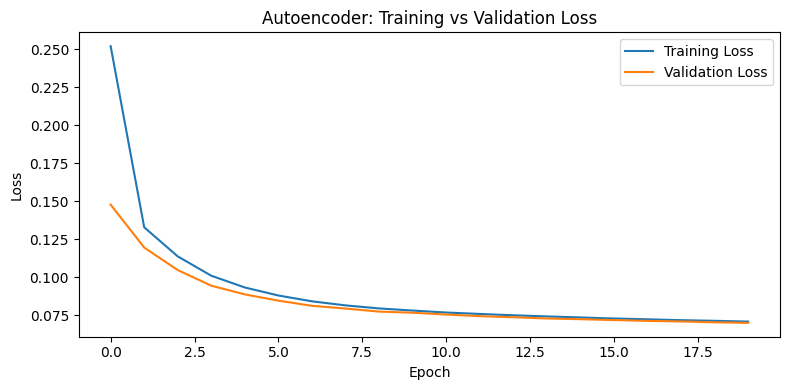

In [28]:
# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'],     label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Autoencoder: Training vs Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

##Step 5: Visual Comparison


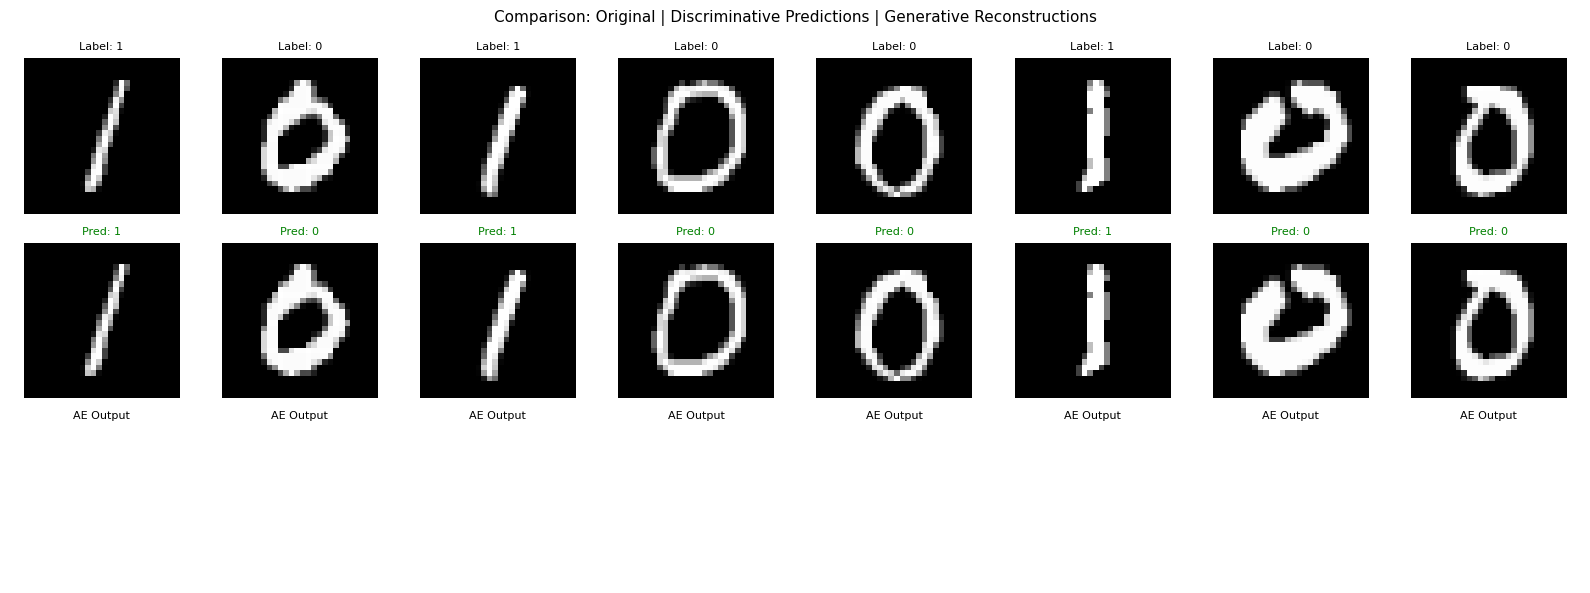

In [31]:
n = 8

plt.figure(figsize=(16, 6))

for i in range(n):
    # Row 1: Original Images
    plt.subplot(3, n, i + 1)
    plt.imshow(X_test[i], cmap='gray')
    if i == 0:
        plt.ylabel('Original\nImages', fontsize=9)
    plt.title(f"Label: {y_test[i]}", fontsize=8)
    plt.axis('off')

    # Row 2: Discriminative Model Predictions
    plt.subplot(3, n, i + n + 1)
    plt.imshow(X_test[i], cmap='gray')
    if i == 0:
        plt.ylabel('Discriminative\nPrediction', fontsize=9)
    color = 'green' if y_pred[i] == y_test[i] else 'red'
    plt.title(f"Pred: {y_pred[i]}", fontsize=8, color=color)
    plt.axis('off')

    # Row 3: Autoencoder Generated Images
    plt.subplot(3, n, i + 2*n + 1)
    if i == 0:
        plt.ylabel('Generated\n(Autoencoder)', fontsize=9)
    plt.title('AE Output', fontsize=8)
    plt.axis('off')

plt.suptitle('Comparison: Original | Discriminative Predictions | Generative Reconstructions', fontsize=11)
plt.tight_layout()
plt.show()